Notebook used to plot the charts from the evaluation benchmarks on pruned models, based on results produced by the other notebooks.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

# CHANGE this to your repo folder
%cd /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
!ls

Mounted at /content/drive
/content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
build		    experiments  pyproject.toml  src	     test.sh
build_and_test.sh   LICENSE	 README.md	 SUPPORT.md
CODE_OF_CONDUCT.md  pipelines	 SECURITY.md	 tests


In [5]:
import os, textwrap

# Where to save logs and models in your Drive
BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs_Qwen2-1.5B-Instruct")
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_Qwen2-1.5B-Instruct")
BASE_EVAL_DIR = os.path.join(BASE_RESULTS_DIR, "eval")

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

sparsities = [0.0, 0.10, 0.25, 0.40, 0.60]
#datasets = ["wikitext2", "squad", "hotpotqa"]
datasets = ["coqa"]
print("Logs in:", LOG_DIR)
print("Models in:", MODEL_DIR)

Logs in: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/logs_Qwen2-1.5B-Instruct
Models in: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_Qwen2-1.5B-Instruct


In [72]:
import os, json
import pandas as pd

def load_results(model, dataset, suffix_candidates, task_key=None,
                 base_subdir="Qwen2-0.5B", eval_subdir=None):
    sparsities = [0.00, 0.10, 0.25, 0.40, 0.60]
    rows = []

    results_dir = os.path.join(
        BASE_EVAL_DIR,
        base_subdir,
        f"{model.replace('/', '-')}_{dataset}"
    )

    if eval_subdir is not None:
        results_dir = os.path.join(results_dir, eval_subdir)

    # normalize suffixes
    suffix_strings = []
    for s in suffix_candidates:
        if isinstance(s, str):
            suffix_strings.append(s)
        elif isinstance(s, (list, tuple)):
            suffix_strings.append("_".join(s))
        else:
            raise ValueError(f"Unsupported suffix candidate: {s}")

    #print(f"[DEBUG] Searching in: {results_dir}")
    #print(f"[DEBUG] Suffixes: {suffix_strings}")

    for sparsity in sparsities:
        s_dot = f"{sparsity:.2f}"          # 0.00
        s_p   = s_dot.replace(".", "p")   # 0p00

        candidate_paths = []
        for suf in suffix_strings:
            candidate_paths.extend([
                os.path.join(results_dir, f"results_s{s_dot}_{suf}.json"),
                os.path.join(results_dir, f"results_ss{s_dot}_{suf}.json"),
                os.path.join(results_dir, f"results_s{s_p}_{suf}.json"),
                os.path.join(results_dir, f"results_ss{s_p}_{suf}.json"),
            ])

        path = None

        #print(f"\n[DEBUG] Sparsity = {sparsity:.2f}")
        #print(f"[DEBUG] Looking in: {results_dir}")
        #print("[DEBUG] Tried paths:")

        for p in candidate_paths:
            if os.path.exists(p):
                #print(f"   ✅ FOUND {p}")
                path = p
                break
            #else:
                #print(f"   ❌ {p}")

        if path is None:
            print(f"[WARN] No file found for sparsity={sparsity:.2f}")
            continue

        #print(f"[DEBUG] Using file: {path}")

        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        metrics = None

        if isinstance(data, dict) and "metrics" in data and isinstance(data["metrics"], dict):
            metrics = data["metrics"]

        elif isinstance(data, dict) and "results" in data and isinstance(data["results"], dict):
            if task_key is None or task_key not in data["results"]:
                print(f"[WARN] Task '{task_key}' not found in {path}. Available: {list(data['results'].keys())}")
                continue
            metrics = data["results"][task_key]

        elif isinstance(data, dict) and task_key is not None and task_key in data and isinstance(data[task_key], dict):
            metrics = data[task_key]

        elif isinstance(data, dict):
            numeric_items = {k: v for k, v in data.items() if isinstance(v, (int, float))}
            if numeric_items:
                metrics = numeric_items

        if metrics is None:
            print(f"[WARN] Could not parse metrics from {path}. Keys: {list(data.keys())}")
            continue

        row = {"sparsity": sparsity}
        for k, v in metrics.items():
            if isinstance(v, (int, float)):
                row[k] = v
        rows.append(row)

    if not rows:
        return pd.DataFrame(columns=["sparsity"])

    return pd.DataFrame(rows).sort_values("sparsity").reset_index(drop=True)

In [110]:
#this should be the best version
import matplotlib.pyplot as plt

def plot_metric_multi(results_dict, metric, metric_title, model_identifier, baseline_em=None, baseline_f1=None):
    plt.figure()
    plotted = False

    for cal_ds, df in results_dict.items():
        # df might be empty because files for this cal_ds don't exist
        if df is None or df.empty:
            print(f"[WARN] Skip {cal_ds}: no data (missing files)")
            continue
        if "sparsity" not in df.columns:
            print(f"[WARN] Skip {cal_ds}: missing 'sparsity' column. Columns: {list(df.columns)}")
            continue
        if metric not in df.columns:
            print(f"[WARN] Skip {cal_ds}: missing metric '{metric}'. Columns: {list(df.columns)}")
            continue

        plt.plot(df["sparsity"], df[metric], marker="o", label=f"cal_ds: {cal_ds}")
        plotted = True

    # ADD BASELINE LINE
    if baseline_em is not None:
        plt.axhline(y=baseline_em, linestyle="--", linewidth=2, label="baseline (EM)")
    if baseline_f1 is not None:
        plt.axhline(y=baseline_f1, linestyle="--", linewidth=2, label="baseline (F1)")


    if not plotted:
        print("[WARN] Nothing to plot (no calibration dataset had squadv2 results).")
        return

    plt.title(f"{metric_title} vs Sparsity ({model_identifier})")
    plt.xlabel("Sparsity")
    plt.ylabel(metric_title)
    plt.grid(True)
    plt.legend()
    plt.ylim([0.0, 70])
    plt.show()

In [ ]:
#plot for CoQA-style metrics as it gives a [0,1] range instead of [0,100].
import matplotlib.pyplot as plt

def plot_metric_multi_coqa(results_dict, metric, metric_title, model_identifier,
                      baseline_em=None, baseline_f1=None):
    plt.figure()
    plotted = False

    for cal_ds, df in results_dict.items():
        if df is None or df.empty:
            print(f"[WARN] Skip {cal_ds}: no data (missing files)")
            continue
        if "sparsity" not in df.columns:
            print(f"[WARN] Skip {cal_ds}: missing 'sparsity'")
            continue
        if metric not in df.columns:
            print(f"[WARN] Skip {cal_ds}: missing metric '{metric}'")
            continue

        values = df[metric] * 100  # percentage
        plt.plot(df["sparsity"], values, marker="o", label=f"cal_ds: {cal_ds}")
        plotted = True

    # ADD BASELINE LINE
    if "em" in metric and baseline_em is not None:
        plt.axhline(y=baseline_em, linestyle="--", linewidth=2, label="baseline (EM)")
    if "f1" in metric and baseline_f1 is not None:
        plt.axhline(y=baseline_f1, linestyle="--", linewidth=2, label="baseline (F1)")

    if not plotted:
        print("[WARN] Nothing to plot.")
        return

    plt.title(f"{metric_title} vs Sparsity ({model_identifier})")
    plt.xlabel("Sparsity")
    plt.ylabel(f"{metric_title}")
    plt.grid(True)
    plt.legend()
    plt.ylim([0, 100])
    plt.show()

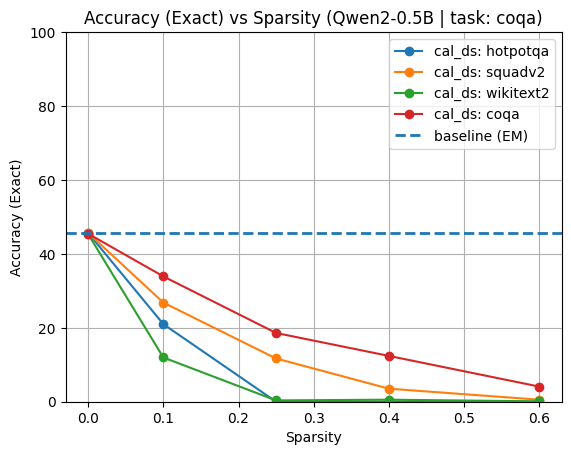

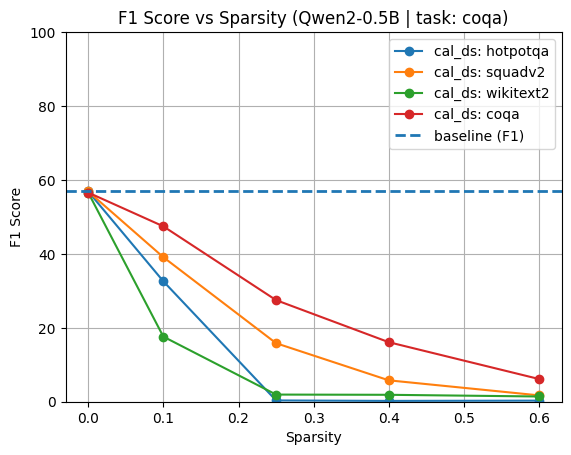

In [45]:
import json

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

results_all = {}

for cal_ds in calibration_datasets:
    df = load_results(
        "Qwen/Qwen2-0.5B",
        cal_ds,
        ["coqa"],     # evaluation task
        "coqa"
    )
    results_all[cal_ds] = df


# Plot EM
# Plot EM
plot_metric_multi_coqa(
    results_all,
    "em,none",
    "Accuracy (Exact)",
    "Qwen2-0.5B | task: coqa",
    baseline_em=45.60
)

# Plot F1
plot_metric_multi_coqa(
    results_all,
    "f1,none",
    "F1 Score",
    "Qwen2-0.5B | task: coqa",
    baseline_f1=57.11
)

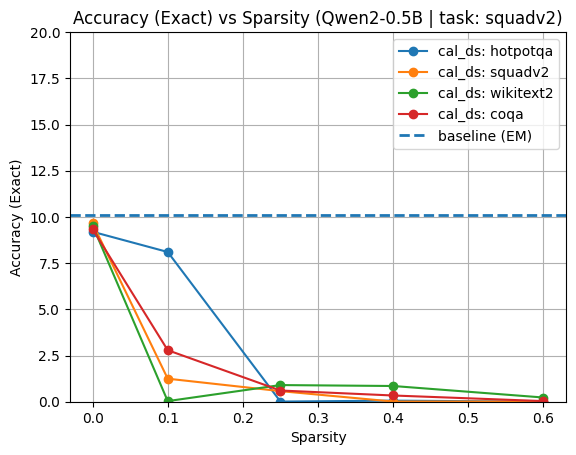

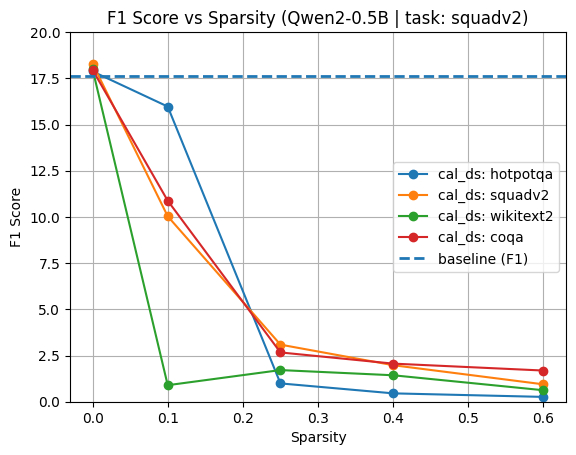

In [95]:
import json

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

results_all = {}

for cal_ds in calibration_datasets:
    df = load_results(
        "Qwen/Qwen2-0.5B",
        cal_ds,
        ["squadv2"],     # evaluation task
        "squadv2",
        base_subdir="Qwen2-0.5B"
    )
    results_all[cal_ds] = df


# Plot EM
plot_metric_multi(
    results_all,
    "exact,none",
    "Accuracy (Exact)",
    "Qwen2-0.5B | task: squadv2",
     baseline_em=10.08
)

# Plot F1
plot_metric_multi(
    results_all,
    "f1,none",
    "F1 Score",
    "Qwen2-0.5B | task: squadv2",
     baseline_f1=17.64
)

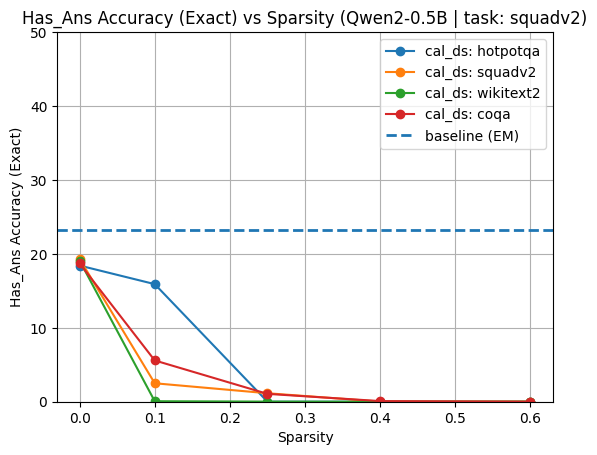

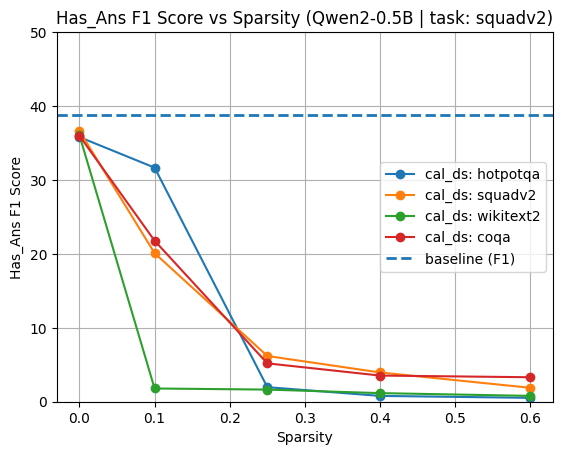

In [97]:
import json

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

results_all = {}

for cal_ds in calibration_datasets:
    df = load_results(
        "Qwen/Qwen2-0.5B",
        cal_ds,
        ["squadv2"],     # evaluation task
        "squadv2"
    )
    results_all[cal_ds] = df


# Plot EM
plot_metric_multi(
    results_all,
    "HasAns_exact,none",
    "Has_Ans Accuracy (Exact)",
    "Qwen2-0.5B | task: squadv2",
    baseline_em=23.18
)

# Plot F1
plot_metric_multi(
    results_all,
    "HasAns_f1,none",
    "Has_Ans F1 Score",
    "Qwen2-0.5B | task: squadv2",
    baseline_f1=38.77
)

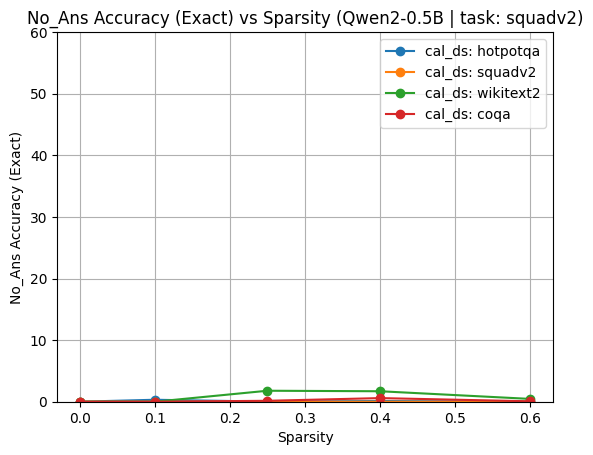

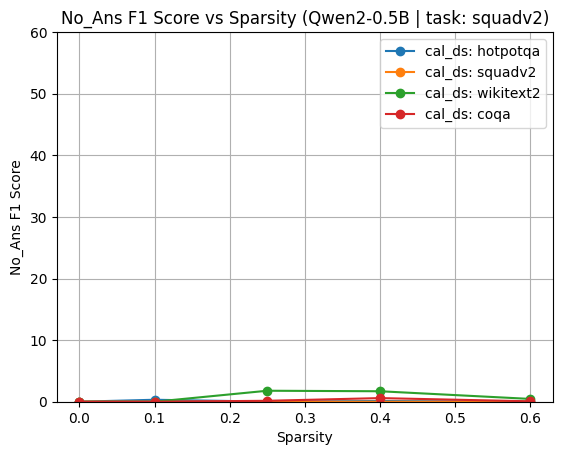

In [108]:
import json

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

results_all = {}

for cal_ds in calibration_datasets:
    df = load_results(
        "Qwen/Qwen2-0.5B",
        cal_ds,
        ["squadv2"],     # evaluation task
        "squadv2"
    )
    results_all[cal_ds] = df


# Plot EM
plot_metric_multi(
    results_all,
    "NoAns_exact,none",
    "No_Ans Accuracy (Exact)",
    "Qwen2-0.5B | task: squadv2",
    #baseline_em=23.18
)

# Plot F1
plot_metric_multi(
    results_all,
    "NoAns_f1,none",
    "No_Ans F1 Score",
    "Qwen2-0.5B | task: squadv2",
    #baseline_f1=38.77
)

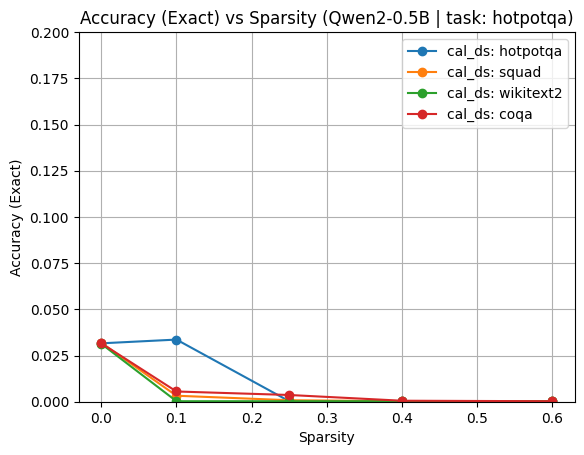

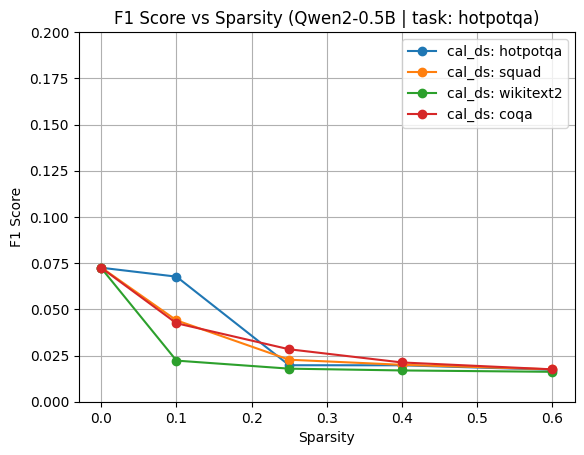

In [ ]:
import json

calibration_datasets = ["hotpotqa", "squad", "wikitext2", "coqa"]

results_all = {}

for cal_ds in calibration_datasets:
    df = load_results(
        "Qwen/Qwen2-0.5B",
        cal_ds,
        ["hotpot"],     # evaluation task
        "metrics"
    )
    results_all[cal_ds] = df


# Plot EM
plot_metric_multi(
    results_all,
    "em",
    "Accuracy (Exact)",
    "Qwen2-0.5B | task: hotpotqa"
)

# Plot F1
plot_metric_multi(
    results_all,
    "f1",
    "F1 Score",
    "Qwen2-0.5B | task: hotpotqa"
)

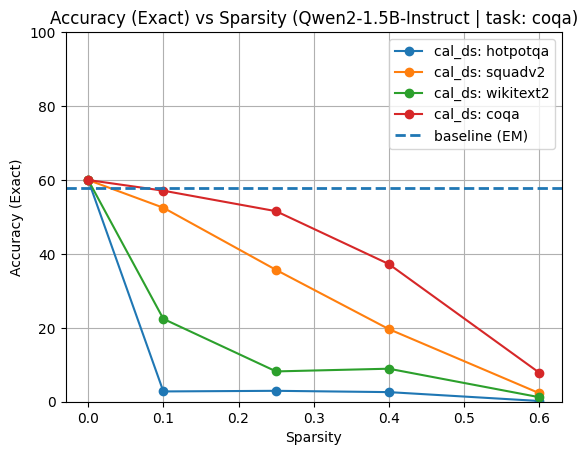

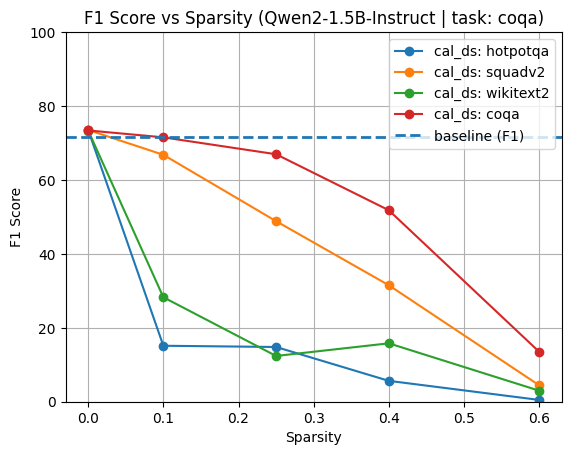

In [75]:
import json

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

results_all = {}

for cal_ds in calibration_datasets:
    df = load_results(
        "Qwen/Qwen2-1.5B-Instruct",
        cal_ds,
        ["coqa"],     # evaluation task
        "coqa",
        base_subdir="Qwen2-1.5B-Instruct"
    )
    results_all[cal_ds] = df


# Plot EM
plot_metric_multi_coqa(
    results_all,
    "em,none",
    "Accuracy (Exact)",
    "Qwen2-1.5B-Instruct | task: coqa",
    baseline_em = 57.92
)

# Plot F1
plot_metric_multi_coqa(
    results_all,
    "f1,none",
    "F1 Score",
    "Qwen2-1.5B-Instruct | task: coqa",
    baseline_f1 = 71.60
)

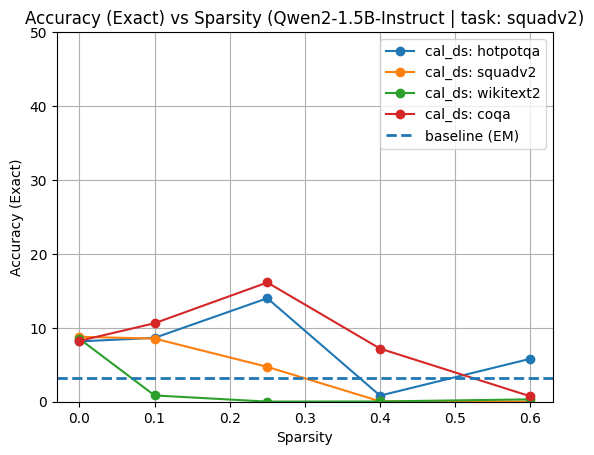

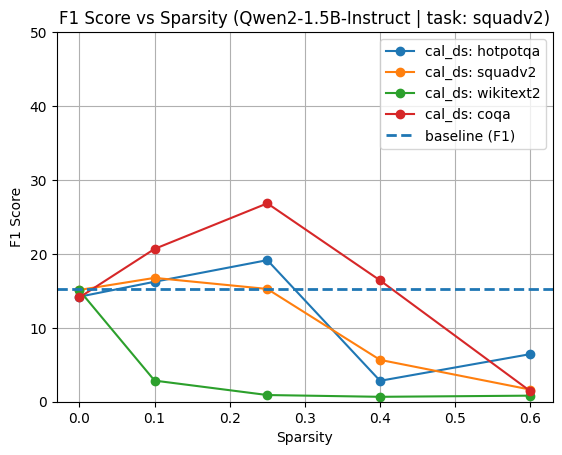

In [77]:
import json

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

results_all = {}

for cal_ds in calibration_datasets:
    df = load_results(
        "Qwen/Qwen2-1.5B-Instruct",
        cal_ds,
        ["squadv2"],     # evaluation task
        "squadv2",
        base_subdir="Qwen2-1.5B-Instruct"
    )
    results_all[cal_ds] = df


# Plot EM
plot_metric_multi(
    results_all,
    "exact,none",
    "Accuracy (Exact)",
    "Qwen2-1.5B-Instruct | task: squadv2",
    baseline_em = 3.15
)

# Plot F1
plot_metric_multi(
    results_all,
    "f1,none",
    "F1 Score",
    "Qwen2-1.5B-Instruct | task: squadv2",
    baseline_f1 = 15.28
)

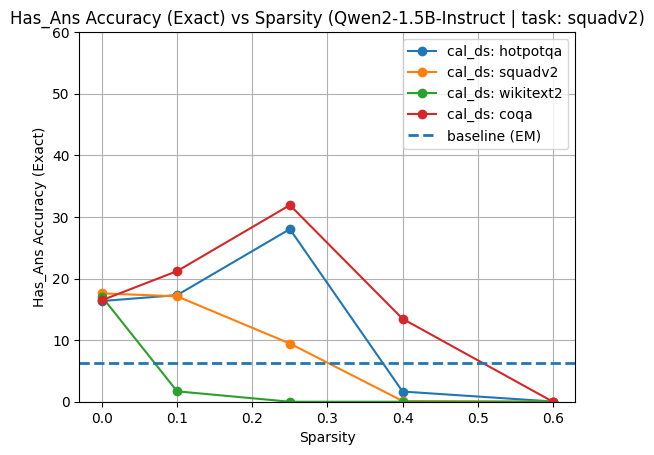

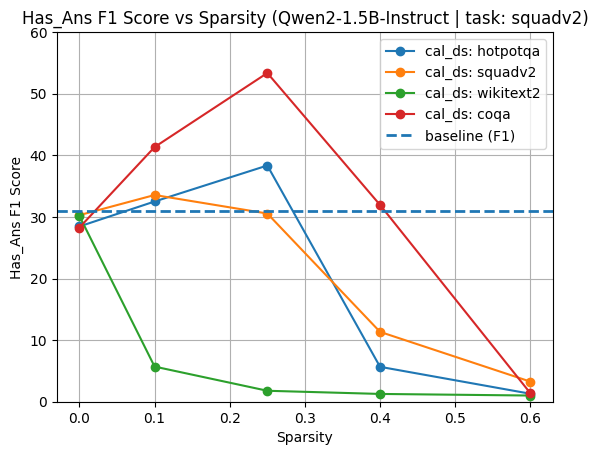

In [100]:
import json

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

results_all = {}

for cal_ds in calibration_datasets:
    df = load_results(
        "Qwen/Qwen2-1.5B-Instruct",
        cal_ds,
        ["squadv2"],     # evaluation task
        "squadv2",
        base_subdir="Qwen2-1.5B-Instruct"
    )
    results_all[cal_ds] = df


# Plot EM
plot_metric_multi(
    results_all,
    "HasAns_exact,none",
    "Has_Ans Accuracy (Exact)",
    "Qwen2-1.5B-Instruct | task: squadv2",
    baseline_em = 6.32
)

# Plot F1
plot_metric_multi(
    results_all,
    "HasAns_f1,none",
    "Has_Ans F1 Score",
    "Qwen2-1.5B-Instruct | task: squadv2",
    baseline_f1 = 30.92
)

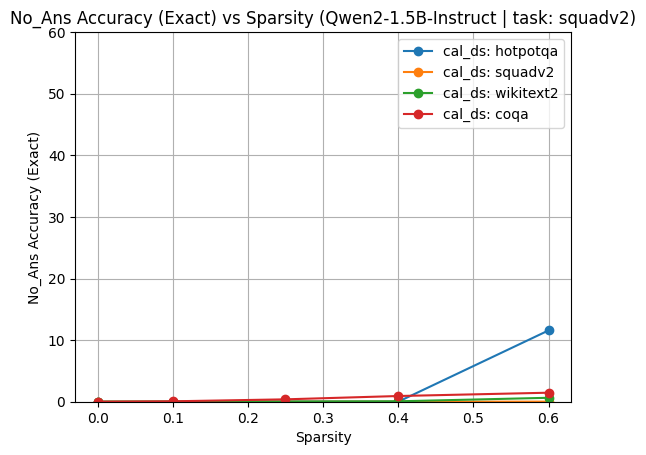

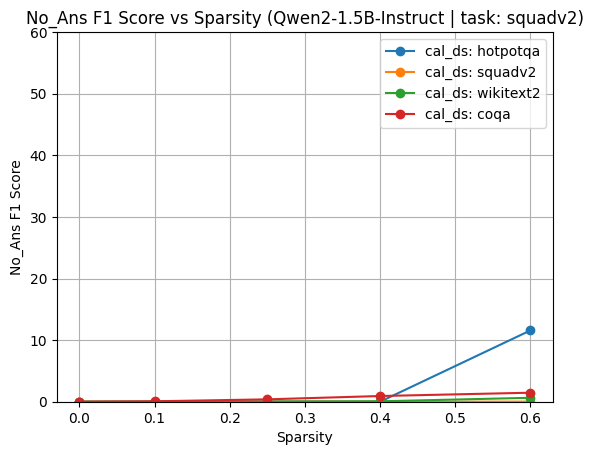

In [107]:
import json

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

results_all = {}

for cal_ds in calibration_datasets:
    df = load_results(
        "Qwen/Qwen2-1.5B-Instruct",
        cal_ds,
        ["squadv2"],     # evaluation task
        "squadv2",
        base_subdir="Qwen2-1.5B-Instruct"
    )
    results_all[cal_ds] = df


# Plot EM
plot_metric_multi(
    results_all,
    "NoAns_exact,none",
    "No_Ans Accuracy (Exact)",
    "Qwen2-1.5B-Instruct | task: squadv2",
    #baseline_em = 6.32
)

# Plot F1
plot_metric_multi(
    results_all,
    "NoAns_f1,none",
    "No_Ans F1 Score",
    "Qwen2-1.5B-Instruct | task: squadv2",
    #baseline_f1 = 30.92
)

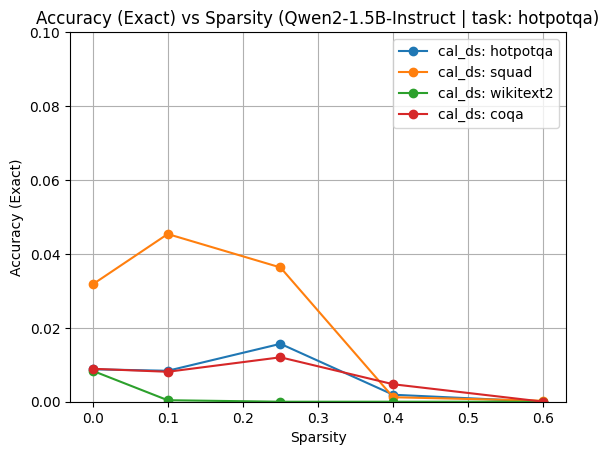

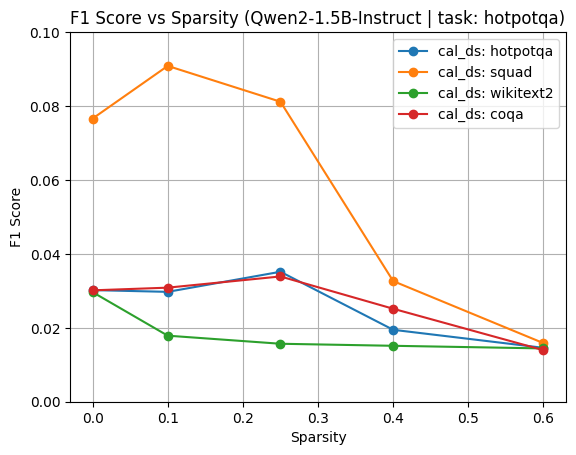

In [ ]:
import json

calibration_datasets = ["hotpotqa", "squad", "wikitext2", "coqa"]

results_all = {}

for cal_ds in calibration_datasets:
    df = load_results(
        "Qwen/Qwen2-1.5B-Instruct",
        cal_ds,
        ["hotpot"],     # evaluation task
        "metrics"
    )
    results_all[cal_ds] = df


# Plot EM
plot_metric_multi(
    results_all,
    "em",
    "Accuracy (Exact)",
    "Qwen2-1.5B-Instruct | task: hotpotqa"
)

# Plot F1
plot_metric_multi(
    results_all,
    "f1",
    "F1 Score",
    "Qwen2-1.5B-Instruct | task: hotpotqa"
)

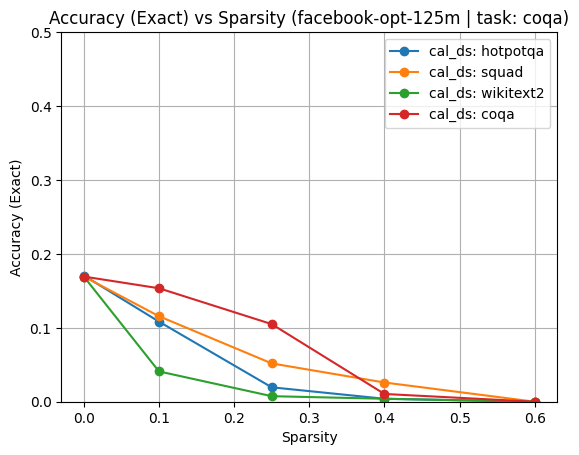

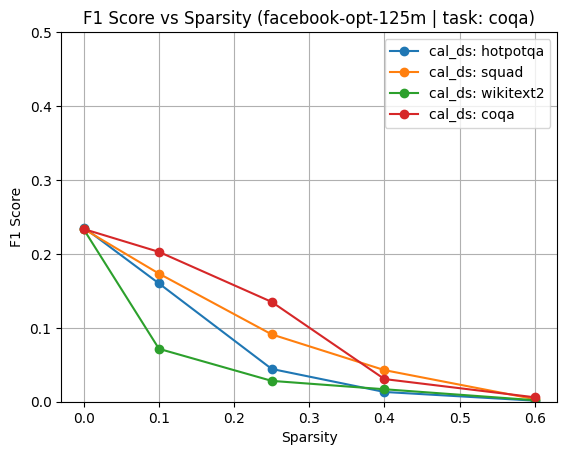

In [ ]:
import json

calibration_datasets = ["hotpotqa", "squad", "wikitext2", "coqa"]

results_all = {}

for cal_ds in calibration_datasets:
    df = load_results(
        "facebook-opt-125m",
        cal_ds,
        ["coqa","squadv2"],     # evaluation task
        "coqa"
    )
    results_all[cal_ds] = df


# Plot EM
plot_metric_multi(
    results_all,
    "em,none",
    "Accuracy (Exact)",
    "facebook-opt-125m | task: coqa"
)

# Plot F1
plot_metric_multi(
    results_all,
    "f1,none",
    "F1 Score",
    "facebook-opt-125m | task: coqa"
)

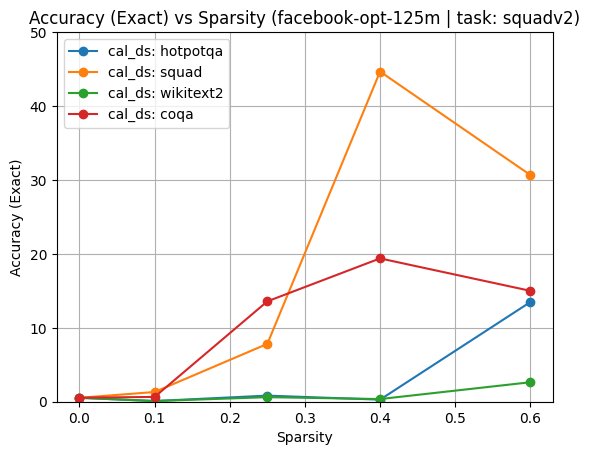

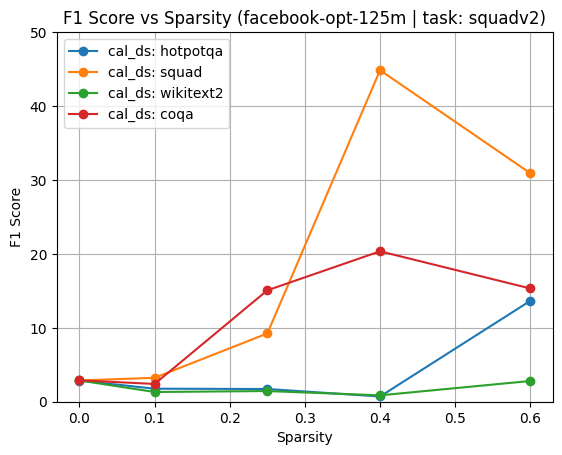

In [ ]:
#to redo it, probably it doesn't see the right dir rn...to update the drive content
calibration_datasets = ["hotpotqa", "squad", "wikitext2", "coqa"]

# try both naming conventions:
# - results_s*_squadv2.json
# - results_s*_coqa_squadv2.json
suffix_candidates = [["squadv2"], ["coqa", "squadv2"]]

results_all = {}
for cal_ds in calibration_datasets:
    results_all[cal_ds] = load_results_multi_suffix(
        model="facebook-opt-125m",
        dataset=cal_ds,
        suffix_candidates=suffix_candidates,
        task_key="squadv2",
        base_subdir="facebook-opt-125m"
    )

plot_metric_multi(results_all, "exact,none", "Accuracy (Exact)", "facebook-opt-125m | task: squadv2")
plot_metric_multi(results_all, "f1,none", "F1 Score", "facebook-opt-125m | task: squadv2")

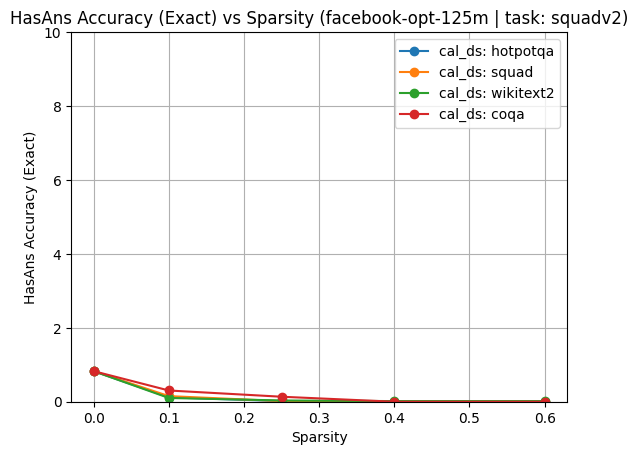

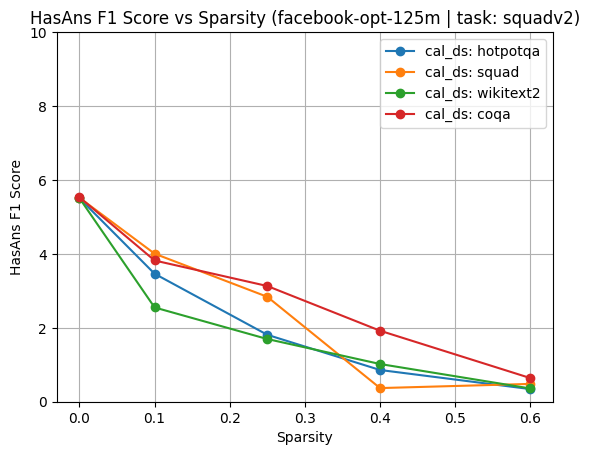

In [ ]:
#to redo it, probably it doesn't see the right dir rn...to update the drive content
#in this case it is better to show HasAns, because in the other plot we have high results for degradation of the model
calibration_datasets = ["hotpotqa", "squad", "wikitext2", "coqa"]

# try both naming conventions:
# - results_s*_squadv2.json
# - results_s*_coqa_squadv2.json
suffix_candidates = [["squadv2"], ["coqa", "squadv2"]]

results_all = {}
for cal_ds in calibration_datasets:
    results_all[cal_ds] = load_results_multi_suffix(
        model="facebook-opt-125m",
        dataset=cal_ds,
        suffix_candidates=suffix_candidates,
        task_key="squadv2",
        base_subdir="facebook-opt-125m"
    )

plot_metric_multi(results_all, "HasAns_exact,none", "HasAns Accuracy (Exact)", "facebook-opt-125m | task: squadv2")
plot_metric_multi(results_all, "HasAns_f1,none", "HasAns F1 Score", "facebook-opt-125m | task: squadv2")

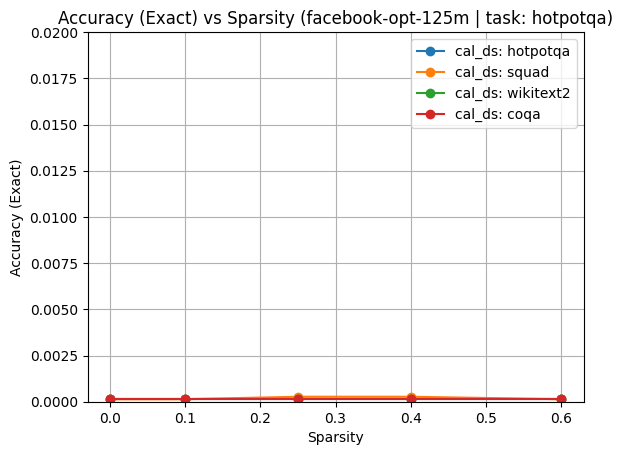

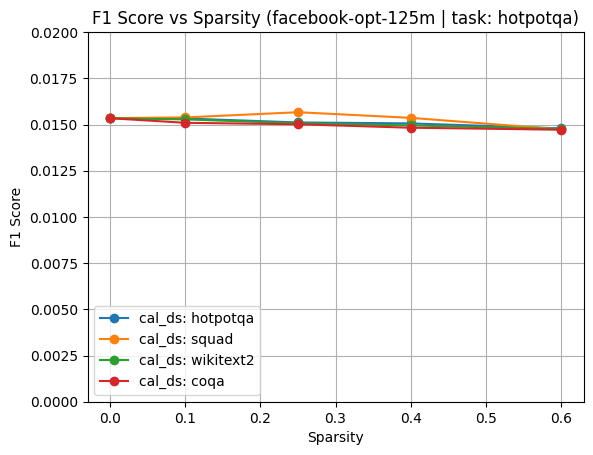

In [ ]:
#to redo it, probably it doesn't see the right dir rn...to update the drive content
calibration_datasets = ["hotpotqa", "squad", "wikitext2", "coqa"]

# try both naming conventions:
# - results_s*_squadv2.json
# - results_s*_coqa_squadv2.json
suffix_candidates = [["hotpot"]]

results_all = {}
for cal_ds in calibration_datasets:
    results_all[cal_ds] = load_results_multi_suffix(
        model="facebook-opt-125m",
        dataset=cal_ds,
        suffix_candidates=suffix_candidates,
        task_key="hotpot",
        base_subdir="facebook-opt-125m"
    )

plot_metric_multi(results_all, "em", "Accuracy (Exact)", "facebook-opt-125m | task: hotpotqa")
plot_metric_multi(results_all, "f1", "F1 Score", "facebook-opt-125m | task: hotpotqa")

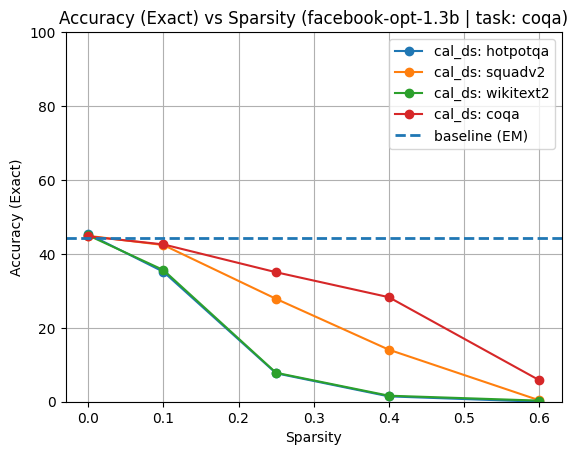

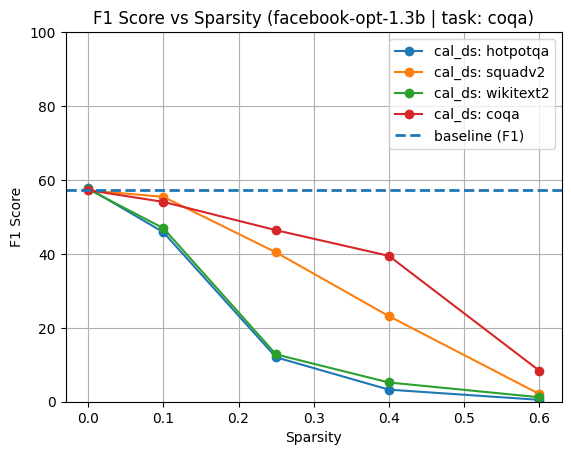

In [86]:

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

# try both naming conventions:
# - results_s*_squadv2.json
# - results_s*_coqa_squadv2.json
suffix_candidates = [["coqa"], ["coqa", "squadv2"]]

results_all = {}
for cal_ds in calibration_datasets:
    results_all[cal_ds] = load_results(
        model="facebook-opt-1.3B",
        dataset=cal_ds,
        suffix_candidates=suffix_candidates,
        task_key="coqa",
        base_subdir="facebook-opt-1.3b"
    )

plot_metric_multi_coqa(results_all, "em,none", "Accuracy (Exact)", "facebook-opt-1.3b | task: coqa", baseline_em = 44.17)
plot_metric_multi_coqa(results_all, "f1,none", "F1 Score", "facebook-opt-1.3b | task: coqa", baseline_f1 = 57.21)

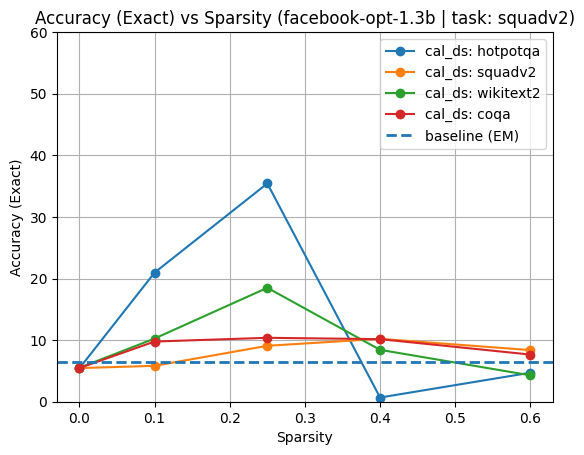

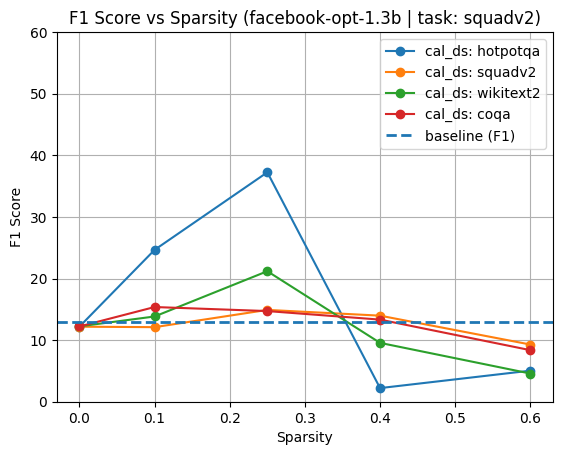

In [89]:

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

# try both naming conventions:
# - results_s*_squadv2.json
# - results_s*_coqa_squadv2.json
suffix_candidates = [["squadv2"], ["coqa", "squadv2"]]

results_all = {}
for cal_ds in calibration_datasets:
    results_all[cal_ds] = load_results(
        model="facebook-opt-1.3B",
        dataset=cal_ds,
        suffix_candidates=suffix_candidates,
        task_key="squadv2",
        base_subdir="facebook-opt-1.3b"
    )

plot_metric_multi(results_all, "exact,none", "Accuracy (Exact)", "facebook-opt-1.3b | task: squadv2", baseline_em = 6.5)
plot_metric_multi(results_all, "f1,none", "F1 Score", "facebook-opt-1.3b | task: squadv2", baseline_f1 = 13.00)

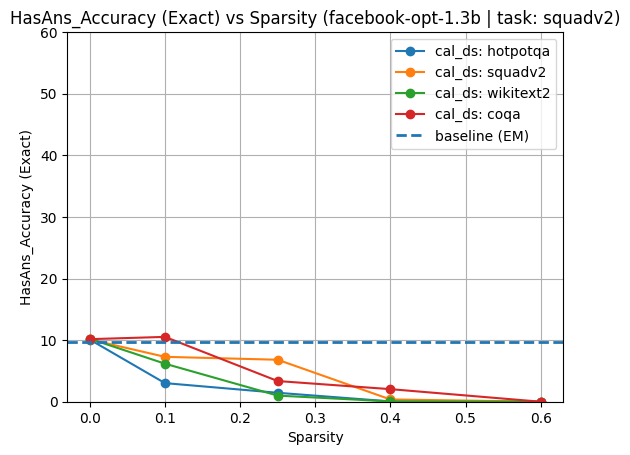

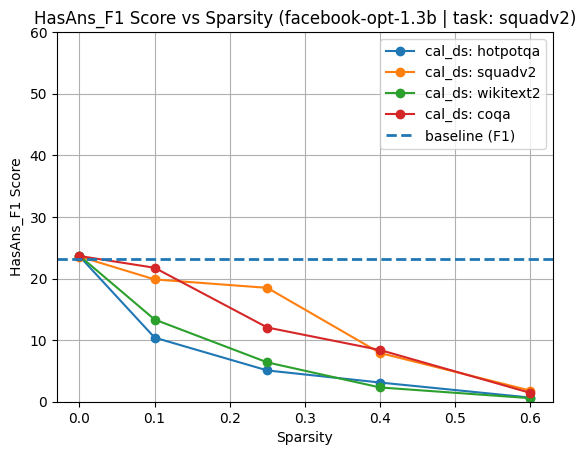

In [101]:

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

# try both naming conventions:
# - results_s*_squadv2.json
# - results_s*_coqa_squadv2.json
suffix_candidates = [["squadv2"], ["coqa", "squadv2"]]

results_all = {}
for cal_ds in calibration_datasets:
    results_all[cal_ds] = load_results(
        model="facebook-opt-1.3B",
        dataset=cal_ds,
        suffix_candidates=suffix_candidates,
        task_key="squadv2",
        base_subdir="facebook-opt-1.3b"
    )

plot_metric_multi(results_all, "HasAns_exact,none", "HasAns_Accuracy (Exact)", "facebook-opt-1.3b | task: squadv2", baseline_em = 9.75)
plot_metric_multi(results_all, "HasAns_f1,none", "HasAns_F1 Score", "facebook-opt-1.3b | task: squadv2",  baseline_f1 = 23.24)

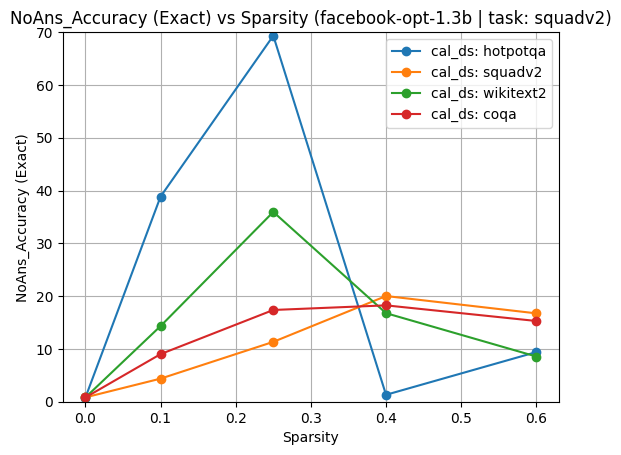

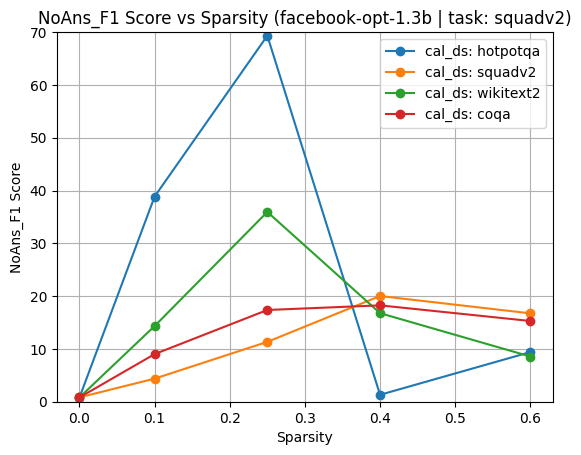

In [113]:

calibration_datasets = ["hotpotqa", "squadv2", "wikitext2", "coqa"]

# try both naming conventions:
# - results_s*_squadv2.json
# - results_s*_coqa_squadv2.json
suffix_candidates = [["squadv2"], ["coqa", "squadv2"]]

results_all = {}
for cal_ds in calibration_datasets:
    results_all[cal_ds] = load_results(
        model="facebook-opt-1.3B",
        dataset=cal_ds,
        suffix_candidates=suffix_candidates,
        task_key="squadv2",
        base_subdir="facebook-opt-1.3b"
    )

plot_metric_multi(results_all, "NoAns_exact,none", "NoAns_Accuracy (Exact)", "facebook-opt-1.3b | task: squadv2")
plot_metric_multi(results_all, "NoAns_f1,none", "NoAns_F1 Score", "facebook-opt-1.3b | task: squadv2")

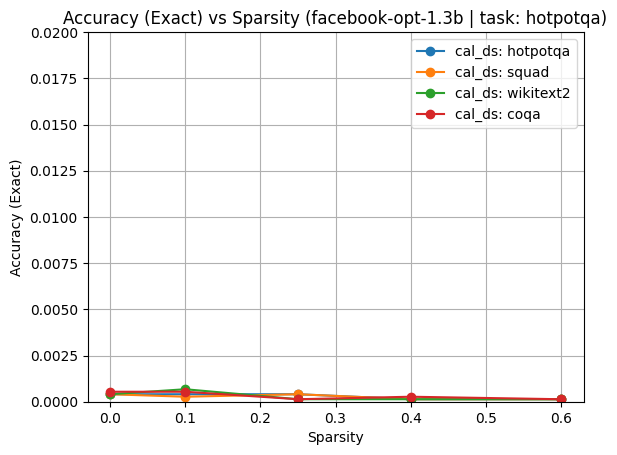

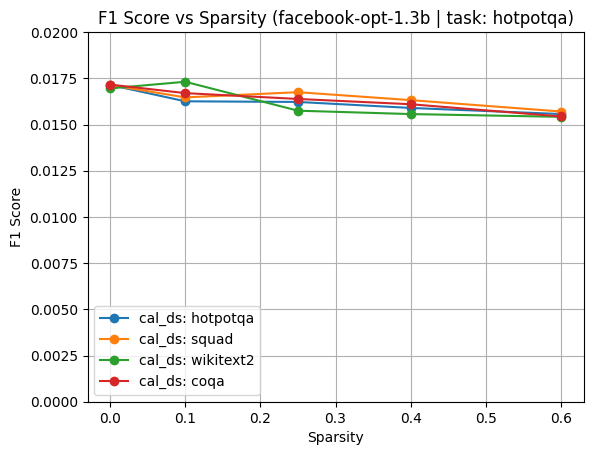

In [ ]:
calibration_datasets = ["hotpotqa", "squad", "wikitext2", "coqa"]

# try both naming conventions:
# - results_s*_squadv2.json
# - results_s*_coqa_squadv2.json
suffix_candidates = [["hotpot"]]

results_all = {}
for cal_ds in calibration_datasets:
    results_all[cal_ds] = load_results_multi_suffix(
        model="facebook-opt-1.3B",
        dataset=cal_ds,
        suffix_candidates=suffix_candidates,
        task_key="hotpot",
        base_subdir="facebook-opt-1.3b"
    )

plot_metric_multi(results_all, "em", "Accuracy (Exact)", "facebook-opt-1.3b | task: hotpotqa")
plot_metric_multi(results_all, "f1", "F1 Score", "facebook-opt-1.3b | task: hotpotqa")